# Réalisez une ACP - Les données des cours

# 1 Preliminary

## 1.1 Context

Ce TP est en lien avec l'activité [Réalisez une ACP](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees/5345201-tp-realisez-une-acp), de la partie 2 du cours  [Réalisez une analyse exploratoire de données](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees).

Nous allons travailler sur le *jeu de données des cours suivis*.

Prenez le temps de bien **lire**, **comprendre** et **tester** le code ci dessous.

<br>

------------------------------

<br>

En cas de question, n'hésitez pas à nous adresser vos remarques ou suggestions via ce [lien](https://openclassrooms.zendesk.com/hc/fr/requests/new).

<br>

-------------------------

<br>

* version : 0.0.3
* last update:  2023-04-19

<br>

## 1.2 Imports

Nous allons importer nos librairies :

In [223]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets, preprocessing
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 1.3 Graphics and Options

On 'charge' `seaborn` :

In [224]:
sns.set()

## 1.4 Data

Nous allons maintenant charger les données. Pour ce faire vous pouvez les retrouver sur cette [page du cours](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees/5148885-telechargez-les-jeux-de-donnees-analyses-dans-ce-cours).

<br>

------------------------


<br>


Si vous utlisez Google Colab et que vous ne savez pas comment importer un fichier .csv, voici une [vidéo](https://youtu.be/6HFlwqK3oeo?t=171) à regarder à partir de 2:53

<br>

-------------------------------------

<br>


Importons notre fichier. Faisons attentions aux options comme `decimal` ou `index_col` :

In [225]:
df = pd.read_csv("df_final.csv", decimal=".", index_col=0)
df.head()

,population,IDH,PIB,import_poulet_tonnes,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist,Continent
Pays,,,,,,,,,,
Afghanistan,40000412.0,0.486,1.516092e+04,32613.38,1.463,97.7,1.95,60165.64,5590.3810,Asia
Afrique du Sud,61502603.0,0.721,4.201178e+05,345579.16,0.319,89.3,3.38,2207246.75,9353.5520,Africa
Albanie,2849635.0,0.794,1.793056e+04,21929.50,-0.630,100.0,2.66,35179.50,1603.5340,Europe
Algérie,44761099.0,0.755,1.862317e+05,0.40,-0.857,99.8,2.45,271904.25,1340.3900,Africa
Allemagne,83697083.0,0.958,4.348297e+06,475448.52,-0.536,100.0,4.20,910325.80,439.8984,Europe


# 2 Data Preparation

Avant de nous jeter dans le grand bain, nous allons devoir étudier et préparer un peu le terrain.

## 2.1 Quick tour

Tout d'abord, faisons un rapide tour de nos données. Commençons par les afficher :

In [226]:
df.head(30)

,population,IDH,PIB,import_poulet_tonnes,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist,Continent
Pays,,,,,,,,,,
Afghanistan,4.000041e+07,0.486,1.516092e+04,32613.38,1.463,97.7,1.950000,60165.64,5590.3810,Asia
Afrique du Sud,6.150260e+07,0.721,4.201178e+05,345579.16,0.319,89.3,3.380000,2207246.75,9353.5520,Africa
Albanie,2.849635e+06,0.794,1.793056e+04,21929.50,-0.630,100.0,2.660000,35179.50,1603.5340,Europe
Algérie,4.476110e+07,0.755,1.862317e+05,0.40,-0.857,99.8,2.450000,271904.25,1340.3900,Africa
Allemagne,8.369708e+07,0.958,4.348297e+06,475448.52,-0.536,100.0,4.200000,910325.80,439.8984,Europe
Angola,3.453243e+07,0.609,6.990571e+04,240448.80,-0.699,48.2,2.050000,295831.67,6510.3220,Africa
Arabie Saoudite,3.132838e+07,0.878,8.741561e+05,597975.48,-1.354,100.0,3.010000,1487242.45,4694.5000,Asia
Argentine,4.531228e+07,0.847,4.865641e+05,6856.16,1.901,100.0,2.890000,2139767.36,11072.2500,South America
Arménie,2.870349e+06,0.786,1.387892e+04,37733.64,1.688,100.0,2.610000,52104.80,3434.0710,Asia


In [227]:
df.tail()

,population,IDH,PIB,import_poulet_tonnes,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist,Continent
Pays,,,,,,,,,,
Égypte,110957008.0,0.738,4.259061e+05,25589.72,0.012,100.0,2.820000,2425360.74,3215.215,Africa
Émirats arabes unis,9789048.0,0.903,4.151788e+05,835237.18,-1.457,100.0,3.960000,509088.14,5249.535,Asia
États-Unis d'Amérique,340161441.0,0.921,2.368120e+07,69962.36,1.701,100.0,3.890000,15432263.59,5838.157,North America
Éthiopie,122138588.0,0.487,9.926012e+04,356.94,2.200,54.2,2.376767,48205.16,5582.502,Africa
Îles Salomon,762591.0,0.577,1.522805e+03,4751.12,-0.875,76.3,2.570000,5035.66,15178.200,Oceania


Quelle est la dimension de notre dataframe?

In [228]:
df.shape

(142, 10)

La méthode `info` nous donne des indications globales :

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, Afghanistan to Îles Salomon
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   population            142 non-null    float64
 1   IDH                   142 non-null    float64
 2   PIB                   142 non-null    float64
 3   import_poulet_tonnes  142 non-null    float64
 4   Politic_score         142 non-null    float64
 5   Access_Elec_Pct       142 non-null    float64
 6   LPI                   142 non-null    float64
 7   consommation_poulet   142 non-null    float64
 8   dist                  142 non-null    float64
 9   Continent             142 non-null    object 
dtypes: float64(9), object(1)
memory usage: 12.2+ KB


Quel est le % de valeurs manquantes par colonne ?

In [230]:
df.isna().mean()

population              0.0
IDH                     0.0
PIB                     0.0
import_poulet_tonnes    0.0
Politic_score           0.0
Access_Elec_Pct         0.0
LPI                     0.0
consommation_poulet     0.0
dist                    0.0
Continent               0.0
dtype: float64

Y a-t-il des lignes en double ?

In [231]:
df.duplicated().sum()

np.int64(0)

Combien y a-t-il de valeurs différentes par colonne ?

In [232]:
df.nunique()

population              142
IDH                     124
PIB                     142
import_poulet_tonnes    142
Politic_score           140
Access_Elec_Pct          58
LPI                     112
consommation_poulet     142
dist                    142
Continent                 6
dtype: int64

Enfin la methode `describe` nous donne une idée de la dispersion globale de nos données :

In [233]:
df.describe()

,population,IDH,PIB,import_poulet_tonnes,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist
count,1.420000e+02,142.000000,1.420000e+02,1.420000e+02,142.000000,142.000000,142.000000,1.420000e+02,142.000000
mean,5.254455e+07,0.739246,6.357098e+05,9.395775e+04,0.192148,87.000000,2.884230,7.685496e+05,5524.394938
std,1.749926e+08,0.147497,2.551203e+06,2.353473e+05,1.428865,23.054957,0.550548,2.182818e+06,3771.854079
min,2.219610e+05,0.413000,5.283354e+02,4.000000e-01,-2.988000,14.200000,1.950000,2.196090e+03,262.384500
25%,4.349239e+06,0.620500,1.905140e+04,3.630457e+03,-0.848000,86.300000,2.497500,5.377004e+04,1984.569500
50%,1.082296e+07,0.754500,6.936072e+04,2.797207e+04,0.021500,100.000000,2.737373,1.369896e+05,5201.299500
75%,3.781528e+07,0.865750,3.643650e+05,7.685479e+04,1.220500,100.000000,3.215000,4.594258e+05,8190.166500
max,1.465659e+09,0.969000,2.368120e+07,2.246646e+06,3.467000,100.000000,4.200000,1.686359e+07,19263.880000


## 2.4 Data Split

Nous allons ensuite séparer nos données. D'un coté `X` la matrice des données :

In [234]:
df_x = df.drop(columns='Continent')

In [235]:
X = df_x.values
X[:5]

array([[ 4.00004120e+07,  4.86000000e-01,  1.51609206e+04,
         3.26133800e+04,  1.46300000e+00,  9.77000000e+01,
         1.95000000e+00,  6.01656400e+04,  5.59038100e+03],
       [ 6.15026030e+07,  7.21000000e-01,  4.20117806e+05,
         3.45579160e+05,  3.19000000e-01,  8.93000000e+01,
         3.38000000e+00,  2.20724675e+06,  9.35355200e+03],
       [ 2.84963500e+06,  7.94000000e-01,  1.79305641e+04,
         2.19295000e+04, -6.30000000e-01,  1.00000000e+02,
         2.66000000e+00,  3.51795000e+04,  1.60353400e+03],
       [ 4.47610990e+07,  7.55000000e-01,  1.86231676e+05,
         4.00000000e-01, -8.57000000e-01,  9.98000000e+01,
         2.45000000e+00,  2.71904250e+05,  1.34039000e+03],
       [ 8.36970830e+07,  9.58000000e-01,  4.34829744e+06,
         4.75448520e+05, -5.36000000e-01,  1.00000000e+02,
         4.20000000e+00,  9.10325800e+05,  4.39898400e+02]])

C'est bien un `np.array` :

In [236]:
type(X)

numpy.ndarray

La forme de cette matrice est conforme à nos attentes :

In [237]:
X.shape

(142, 9)

Nous enregistrons les noms de nos cours dans une variable `names` :

In [238]:
names = df_x.index
names

Index(['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne',
       'Angola', 'Arabie Saoudite', 'Argentine', 'Arménie', 'Australie',
       ...
       'Venezuela', 'Viet Nam', 'Yémen', 'Zambie', 'Zimbabwe', 'Égypte',
       'Émirats arabes unis', 'États-Unis d'Amérique', 'Éthiopie',
       'Îles Salomon'],
      dtype='object', name='Pays', length=142)

et nos colonnes, nos features, dans une variable `features` :

In [239]:
features = df_x.columns
features

Index(['population', 'IDH', 'PIB', 'import_poulet_tonnes', 'Politic_score',
       'Access_Elec_Pct', 'LPI', 'consommation_poulet', 'dist'],
      dtype='object')

# 3 About PCA

Nous pouvons - *enfin* - commencer notre ACP, ou notre PCA !

## 3.1 Scaling

Commençons par scaler les données. On instancie :

In [240]:
scaler = StandardScaler()

On fit :

In [241]:
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


On transforme :

In [242]:
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-0.07193754, -1.72303517, -0.24409876, -0.26157732,  0.89256224,
         0.46575129, -1.70291637, -0.32567602,  0.01755626],
       [ 0.05137225, -0.12414516, -0.08480514,  1.0729339 ,  0.08909251,
         0.10011476,  0.90368983,  0.66143392,  1.01878587],
       [-0.28498814,  0.37253131, -0.24300929, -0.30713424, -0.57742215,
         0.56586606, -0.40872728, -0.33716327, -1.04318461],
       [-0.04463617,  0.10718361, -0.17680646, -0.40064169, -0.7368519 ,
         0.55716042, -0.7915156 , -0.22833024, -1.11319673],
       [ 0.17865215,  1.48835243,  1.46038145,  1.62670728, -0.51140279,
         0.56586606,  2.39838709,  0.06518091, -1.3527816 ]])

Rappelons qu'on peut faire les 2 opérations en une seule :

In [243]:
X_scaled = scaler.fit_transform(X)

On espère avoir une moyenne à 0 et un écart type à 1 :

In [244]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8
mean,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3.2 PCA

Nous allons travailler que sur les 6 premières composantes :

In [245]:
n_components = 8

On instancie notre ACP :

In [246]:
pca = PCA(n_components=n_components)

On l'entraine sur les données scalées :

In [247]:
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## 3.3 Explained variance & scree plot

Intéressons nous maintenant à la variance *captée* par chaque nouvelle composante. Grace à `scikit-learn` on peut utiliser l'attribut `explained_variance_ratio_` :

In [248]:
pca.explained_variance_ratio_

array([0.36499139, 0.24636349, 0.11790821, 0.09702878, 0.06137365,
       0.04945136, 0.04175465, 0.01109873])

Ici la 1ère composante *capte* 47% de la variance de nos données initiales, la 2ème 16% etc etc.

Enregistrons cela dans une variable :

In [249]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([36.5 , 24.64, 11.79,  9.7 ,  6.14,  4.95,  4.18,  1.11])

Les 2 premières composantes *captent* donc `47+16 = 63%` de la variance, les 3 premières `47+16+13 = 76%` de la variance etc etc.

Dans le jargon, cela s'appelle une *somme cumulée*. Et pour faire une somme cumulée `numpy` dispose de la fonction `cumsum` :

In [250]:
scree_cum = scree.cumsum().round()
scree_cum

array([36., 61., 73., 83., 89., 94., 98., 99.])

Définisons ensuite une variable avec la liste de nos composantes :

In [251]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8]

On peut enfin l'afficher de façon graphique :

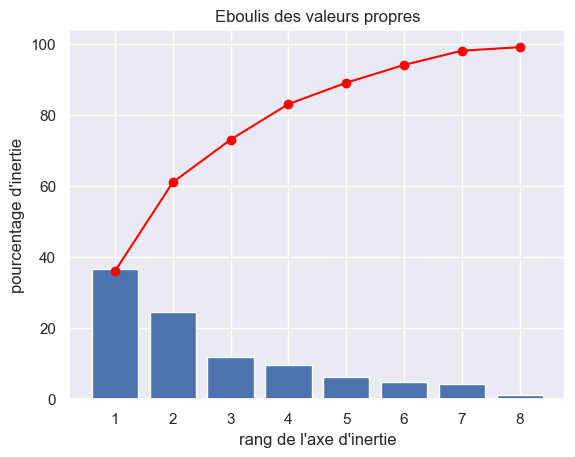

In [252]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée.

On voit ici que près de 80% de la variance est comprise dans les 3 premières composantes, et près de 90% dans les 4 premières.

## 3.4 Components

Intéressons nous maintenant à nos fameuses composantes. Nous avons dit dans le cours que c'est bien par un calcul que l'on obtient ces composantes.

La formule de ce calcul nous est donnée par l'attribut `components_`. Cette variable est généralement nommée `pcs` :

In [253]:
pcs = pca.components_
pcs

array([[ 0.37589826,  0.30547933,  0.45564773,  0.3870648 , -0.01368989,
         0.26758784,  0.34750385,  0.46065002, -0.05657599],
       [-0.33186504,  0.5230774 , -0.21821059, -0.16705865, -0.20536793,
         0.40217042,  0.39034582, -0.29265047, -0.31432465],
       [-0.0055388 ,  0.04552477,  0.00196287, -0.18188396,  0.87996341,
         0.26109671, -0.14504209,  0.07101887, -0.31019865],
       [-0.06478487,  0.15476452, -0.07597651, -0.18244788,  0.12431235,
         0.42078635, -0.01753604,  0.05660092,  0.85835035],
       [ 0.20432506, -0.04060273, -0.46247715,  0.68088746, -0.00693381,
         0.35602562, -0.31281816, -0.23020114, -0.0382066 ],
       [-0.45111095,  0.07847594, -0.05596479,  0.49767853,  0.37100636,
        -0.41260674,  0.42134525, -0.08742295,  0.21554542],
       [ 0.67223713, -0.0285299 , -0.37711823, -0.20029814,  0.15263941,
        -0.1997498 ,  0.49253528, -0.22936073,  0.08092999],
       [ 0.15619386,  0.76969105, -0.11106822, -0.02129062,  0

Affichons la même chose mais version `pandas` :

In [254]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8
0,0.375898,0.305479,0.455648,0.387065,-0.013690,0.267588,0.347504,0.460650,-0.056576
1,-0.331865,0.523077,-0.218211,-0.167059,-0.205368,0.402170,0.390346,-0.292650,-0.314325
2,-0.005539,0.045525,0.001963,-0.181884,0.879963,0.261097,-0.145042,0.071019,-0.310199
3,-0.064785,0.154765,-0.075977,-0.182448,0.124312,0.420786,-0.017536,0.056601,0.858350
4,0.204325,-0.040603,-0.462477,0.680887,-0.006934,0.356026,-0.312818,-0.230201,-0.038207
5,-0.451111,0.078476,-0.055965,0.497679,0.371006,-0.412607,0.421345,-0.087423,0.215545
6,0.672237,-0.028530,-0.377118,-0.200298,0.152639,-0.199750,0.492535,-0.229361,0.080930
7,0.156194,0.769691,-0.111068,-0.021291,0.027564,-0.428761,-0.422909,0.065167,0.051915


Intéressant... Mais pas encore très clair...
Continuons le travail :

In [255]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,population,IDH,PIB,import_poulet_tonnes,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist
F1,0.38,0.31,0.46,0.39,-0.01,0.27,0.35,0.46,-0.06
F2,-0.33,0.52,-0.22,-0.17,-0.21,0.40,0.39,-0.29,-0.31
F3,-0.01,0.05,0.00,-0.18,0.88,0.26,-0.15,0.07,-0.31
F4,-0.06,0.15,-0.08,-0.18,0.12,0.42,-0.02,0.06,0.86
F5,0.20,-0.04,-0.46,0.68,-0.01,0.36,-0.31,-0.23,-0.04
F6,-0.45,0.08,-0.06,0.50,0.37,-0.41,0.42,-0.09,0.22
F7,0.67,-0.03,-0.38,-0.20,0.15,-0.20,0.49,-0.23,0.08
F8,0.16,0.77,-0.11,-0.02,0.03,-0.43,-0.42,0.07,0.05



Dans certains cas, on voudra afficher ce dataframe comme cela :

In [256]:
pcs.T

,F1,F2,F3,F4,F5,F6,F7,F8
population,0.375898,-0.331865,-0.005539,-0.064785,0.204325,-0.451111,0.672237,0.156194
IDH,0.305479,0.523077,0.045525,0.154765,-0.040603,0.078476,-0.028530,0.769691
PIB,0.455648,-0.218211,0.001963,-0.075977,-0.462477,-0.055965,-0.377118,-0.111068
import_poulet_tonnes,0.387065,-0.167059,-0.181884,-0.182448,0.680887,0.497679,-0.200298,-0.021291
Politic_score,-0.013690,-0.205368,0.879963,0.124312,-0.006934,0.371006,0.152639,0.027564
Access_Elec_Pct,0.267588,0.402170,0.261097,0.420786,0.356026,-0.412607,-0.199750,-0.428761
LPI,0.347504,0.390346,-0.145042,-0.017536,-0.312818,0.421345,0.492535,-0.422909
consommation_poulet,0.460650,-0.292650,0.071019,0.056601,-0.230201,-0.087423,-0.229361,0.065167
dist,-0.056576,-0.314325,-0.310199,0.858350,-0.038207,0.215545,0.080930,0.051915


Et pour une représentation plus *visuelle*, comme cela :

<Axes: >

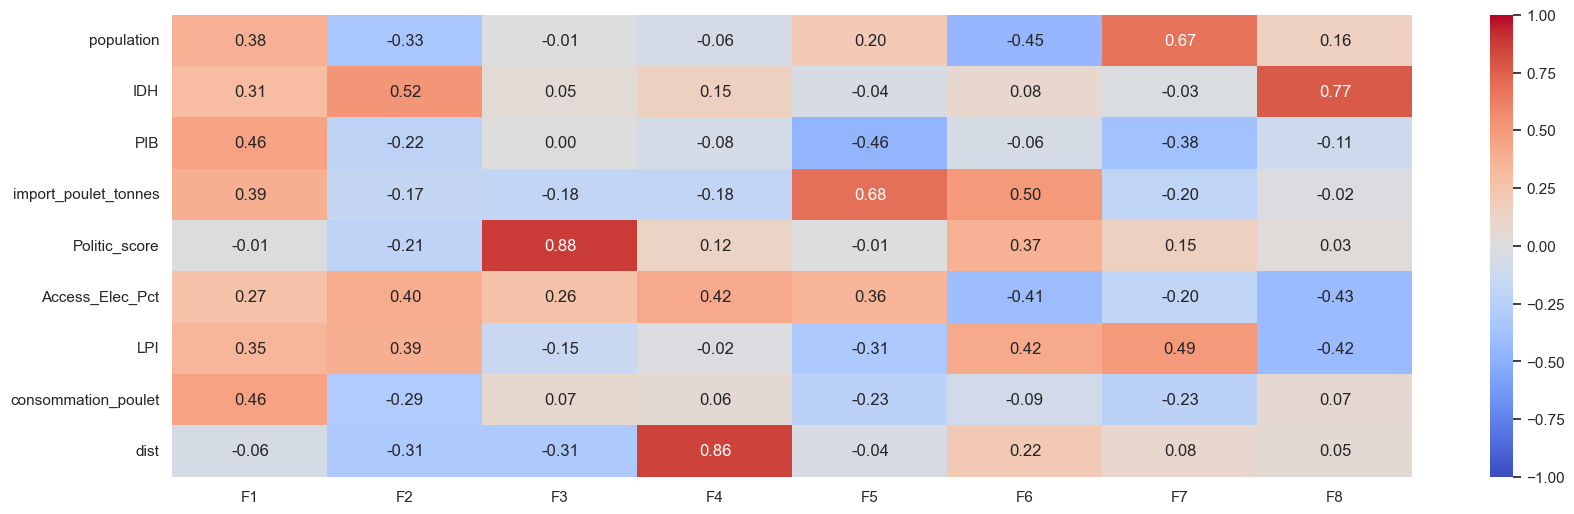

In [257]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

## 3.5 Correlation graph

Définissons nos axes x et y. Nous allons utiliser les 2 premières composantes. Comme - en code - on commence à compter à partir de 0, cela nous donne :

In [258]:
x, y = 0,1

Pour la partie graphique :

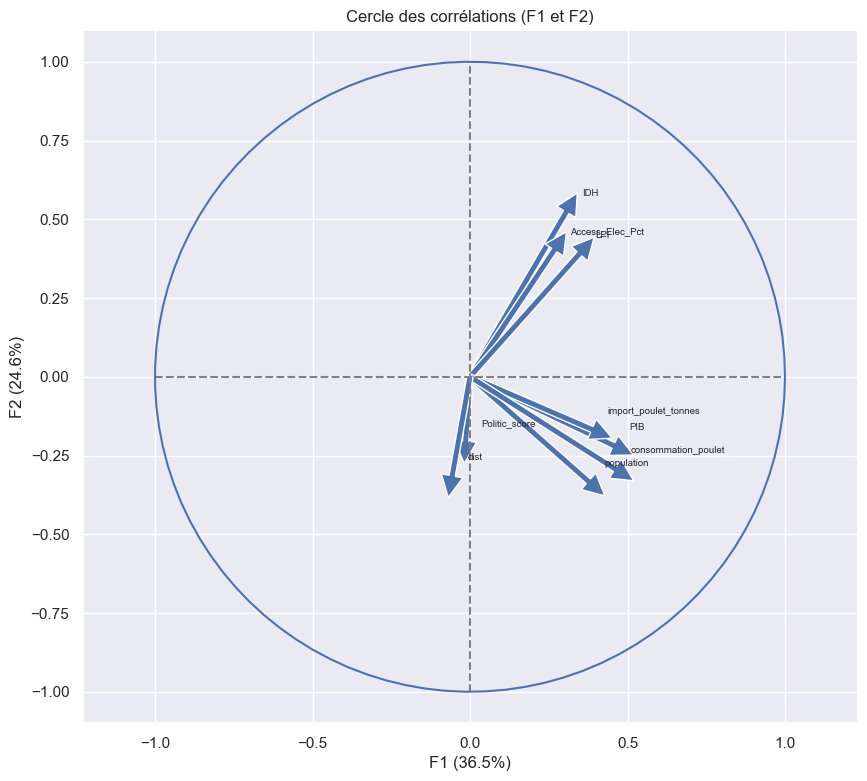

In [259]:
fig, ax = plt.subplots(figsize=(10, 9))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             features[i], size='xx-small')

# affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


# nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
plt.show(block=False)

On peut en faire une fonction :

In [260]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

Essayons cette fonction pour F1 et F2

-- **ATTENTION** -- Encore une fois Pour F1 et F2 il faut bien préciser  0 et 1  😀

In [261]:
x_y = (0,1)
x_y

(0, 1)

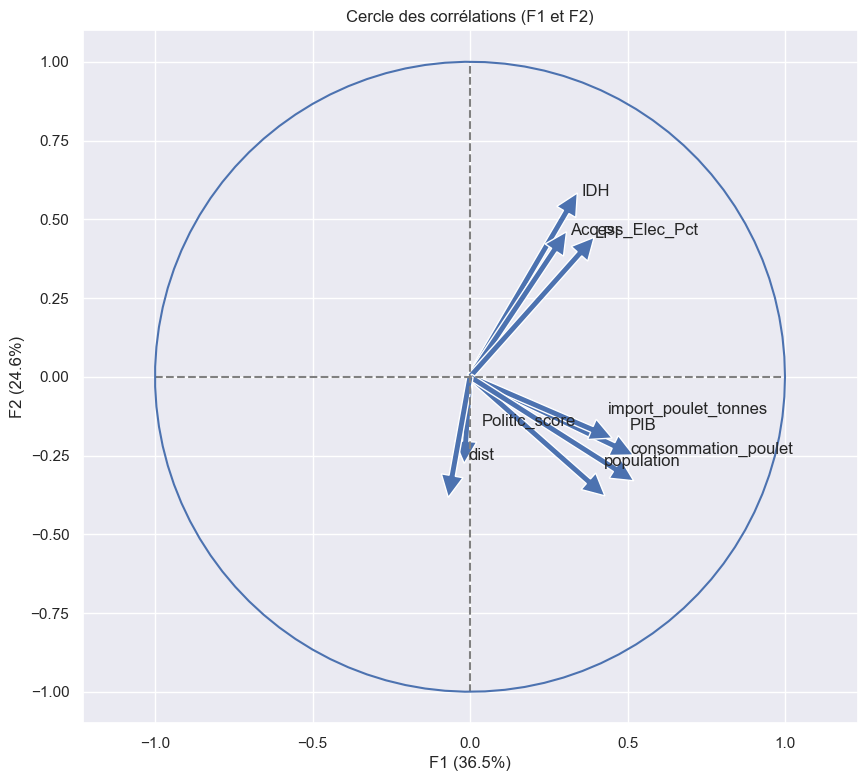

In [262]:
correlation_graph(pca, x_y, features)

Essayons pour F3 et F4 :

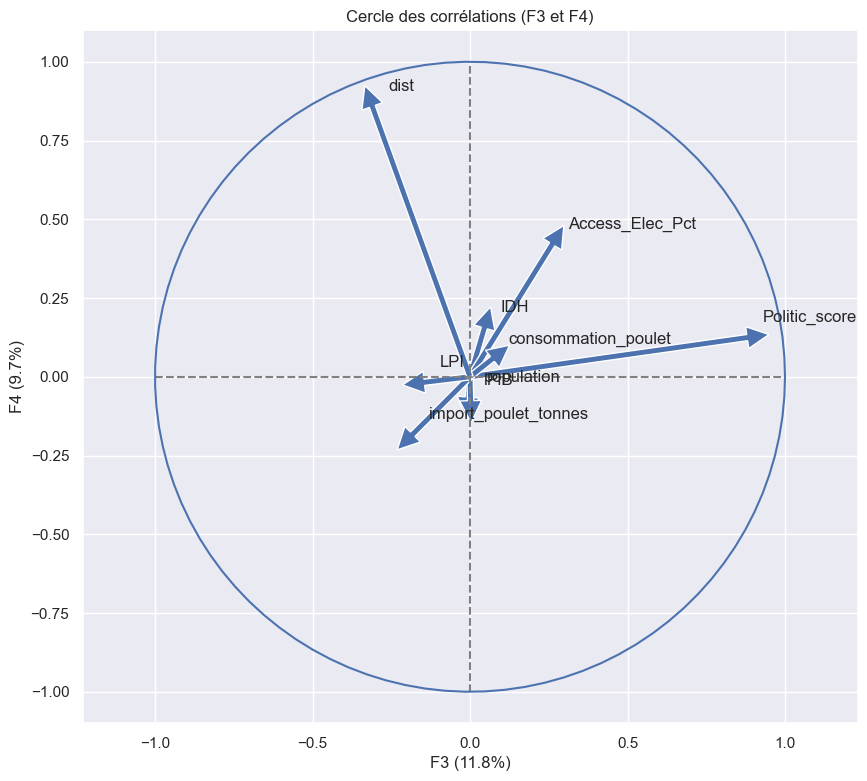

In [263]:
correlation_graph(pca, (2,3), features)

## 3.6 Projection

Travaillons maintenant sur la projection de nos dimensions. Tout d'abord calculons les coordonnées de nos individus dans le nouvel espace :

In [264]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-1.39623886, -1.35137119,  1.09450298,  0.13770233,  0.7566806 ,
        -0.76557131, -0.57417535, -0.77998807],
       [ 0.94469688, -0.38180415, -0.49683914,  0.73741533,  0.34645284,
         1.04008668,  0.22459469, -0.42760778],
       [-0.30193906,  1.00696017,  0.07249125, -0.59038962,  0.28070215,
        -0.79675873, -0.45862075,  0.11393858],
       [-0.3777501 ,  0.65955072,  0.01861948, -0.70570141,  0.34167118,
        -1.21769801, -0.53747499,  0.10656246],
       [ 2.91530576,  1.80374699, -0.452115  , -1.21396825, -0.10028632,
         1.05410624,  0.06683901, -0.36035734]])

Rappelons que :

In [265]:
x_y

(0, 1)

Accrochez vous, car voici la fonction.


Pour info, sachez que nous reviendrons dessus lors du TP de la 3e partie. Pas besoin de trop rentrer dans le détail pour l'instant, mais lisez la quand même le code, au moins une fois, en diagonale...

In [266]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()



Essayons la version *simple* avec F1 et F2, les couleurs correspondent au niveau de LPI :

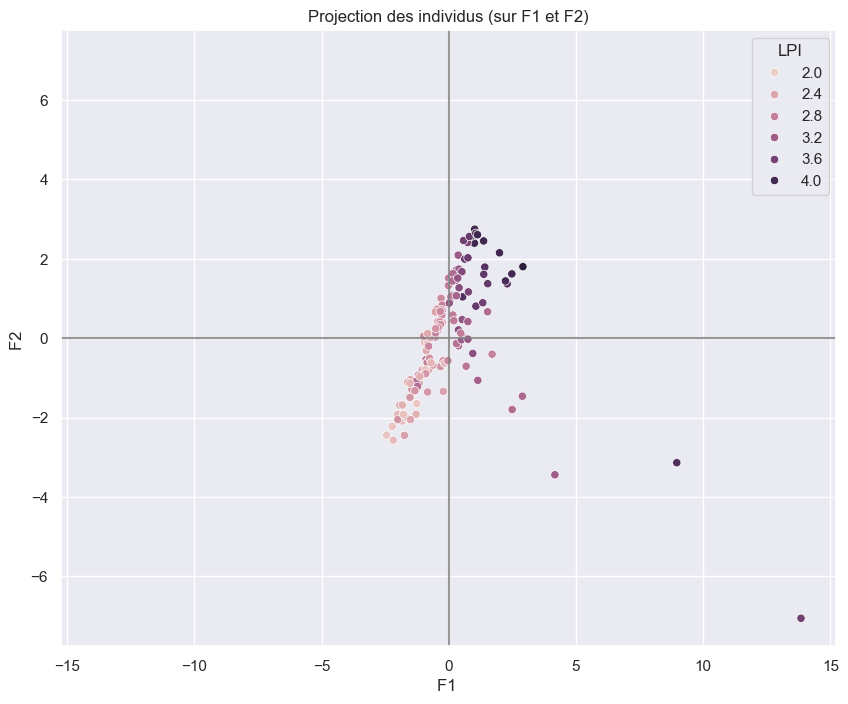

In [267]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, clusters=df_x['LPI'])

Intéressant, mais il manque quelques éléments...

Essayons la version plus *élaborée* avec F1 et F2 :

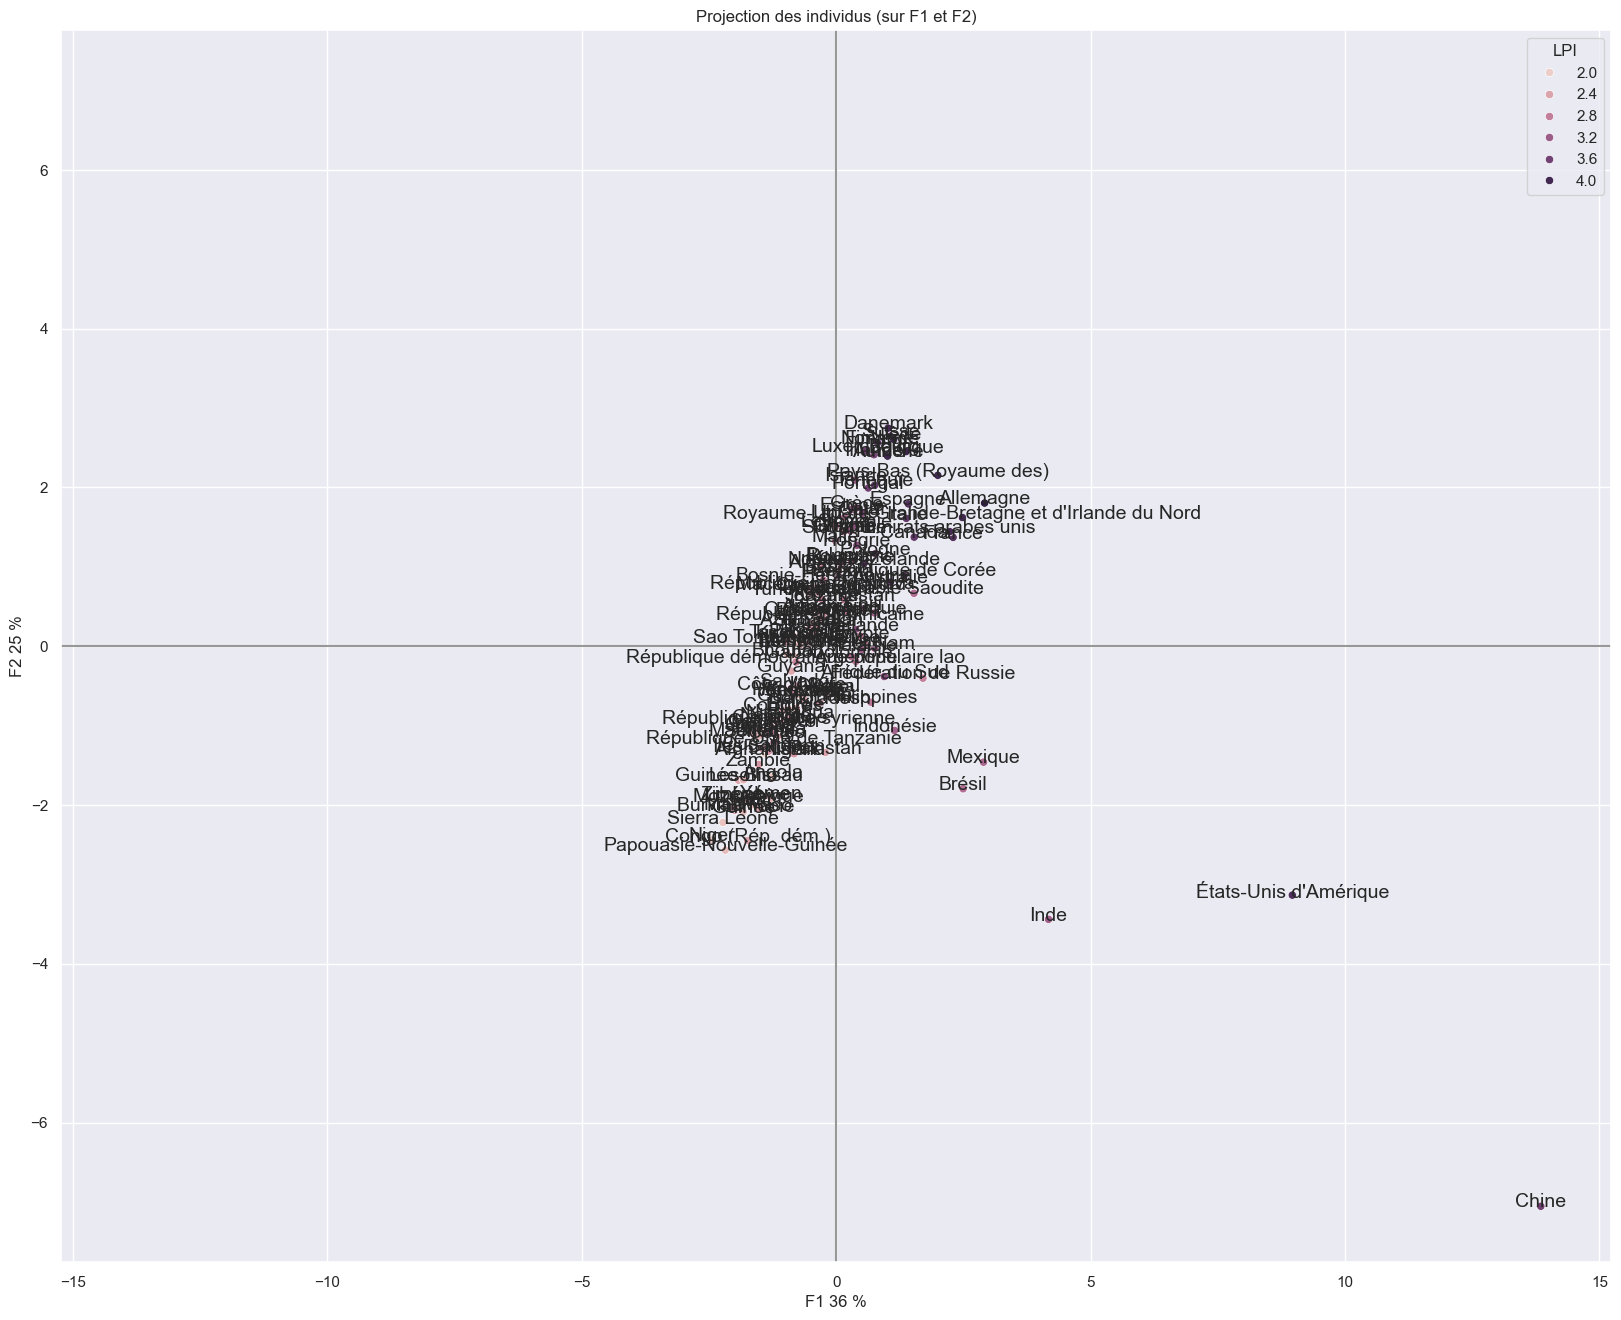

In [268]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df_x['LPI'], marker="o")

Beaucoup mieux !

Essayons avec F2 et F3 :

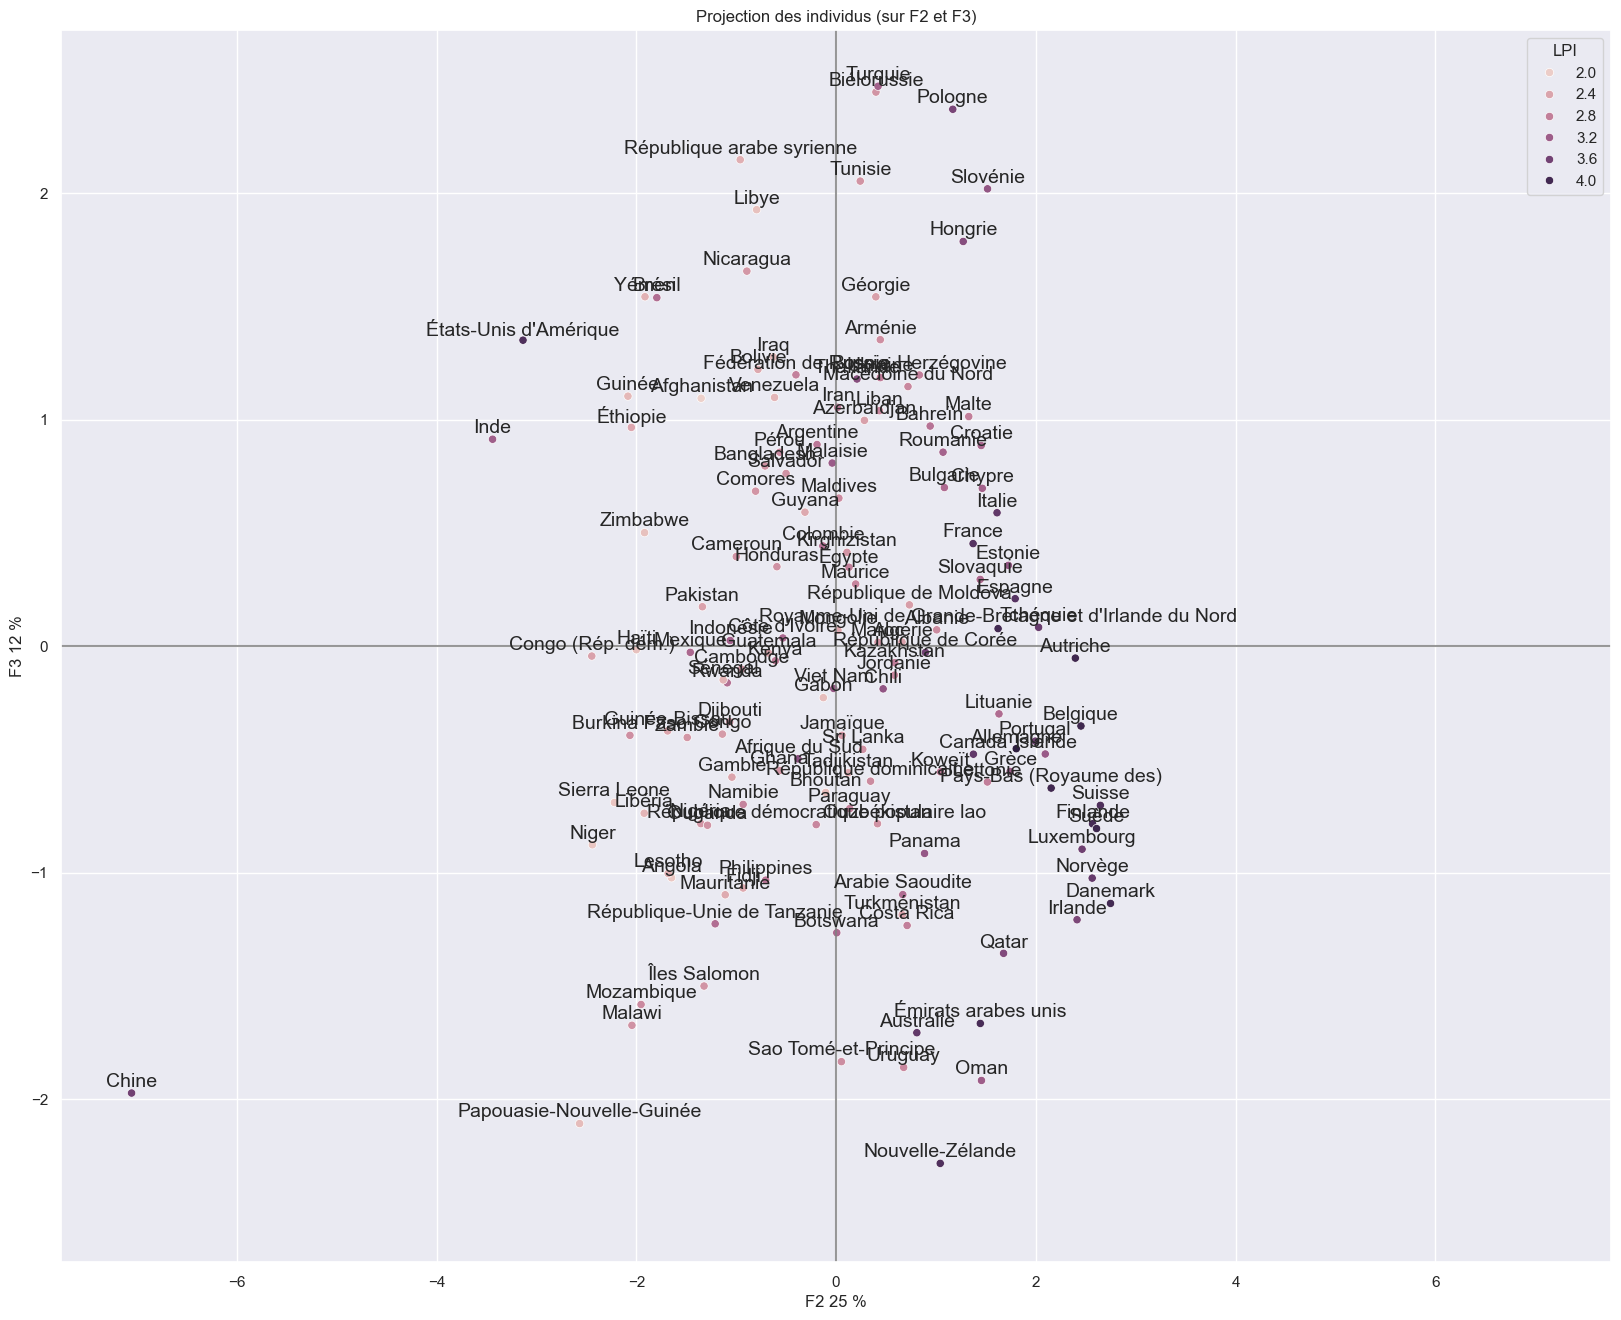

In [269]:
x_y = 1,2
display_factorial_planes(X_proj, x_y, pca, labels=names, figsize=(20,16), clusters=df_x['LPI'],marker="o")

# 4 Conclusion

Vous êtes arrivé au bout de ce travail, Bravo!

Il ne reste plus qu'à vous entrainer sur d'autres jeux de données 😀.

<br>

------------------

<br>

En cas de questions, n'hésitez pas à nous adresser vos questions, remarques ou suggestions sur le [formulaire](https://openclassrooms.zendesk.com/hc/fr/requests/new) .



In [270]:
Z = linkage(X_scaled, method="ward")
Z[:10]

array([[ 18.        ,  76.        ,   0.24398842,   2.        ],
       [ 21.        , 106.        ,   0.31214391,   2.        ],
       [ 41.        , 122.        ,   0.31369766,   2.        ],
       [  2.        , 111.        ,   0.4179685 ,   2.        ],
       [  8.        ,  52.        ,   0.41842206,   2.        ],
       [ 47.        ,  74.        ,   0.42098137,   2.        ],
       [ 73.        , 117.        ,   0.42802482,   2.        ],
       [ 36.        , 121.        ,   0.49122559,   2.        ],
       [112.        , 120.        ,   0.49845854,   2.        ],
       [ 75.        ,  91.        ,   0.49887463,   2.        ]])

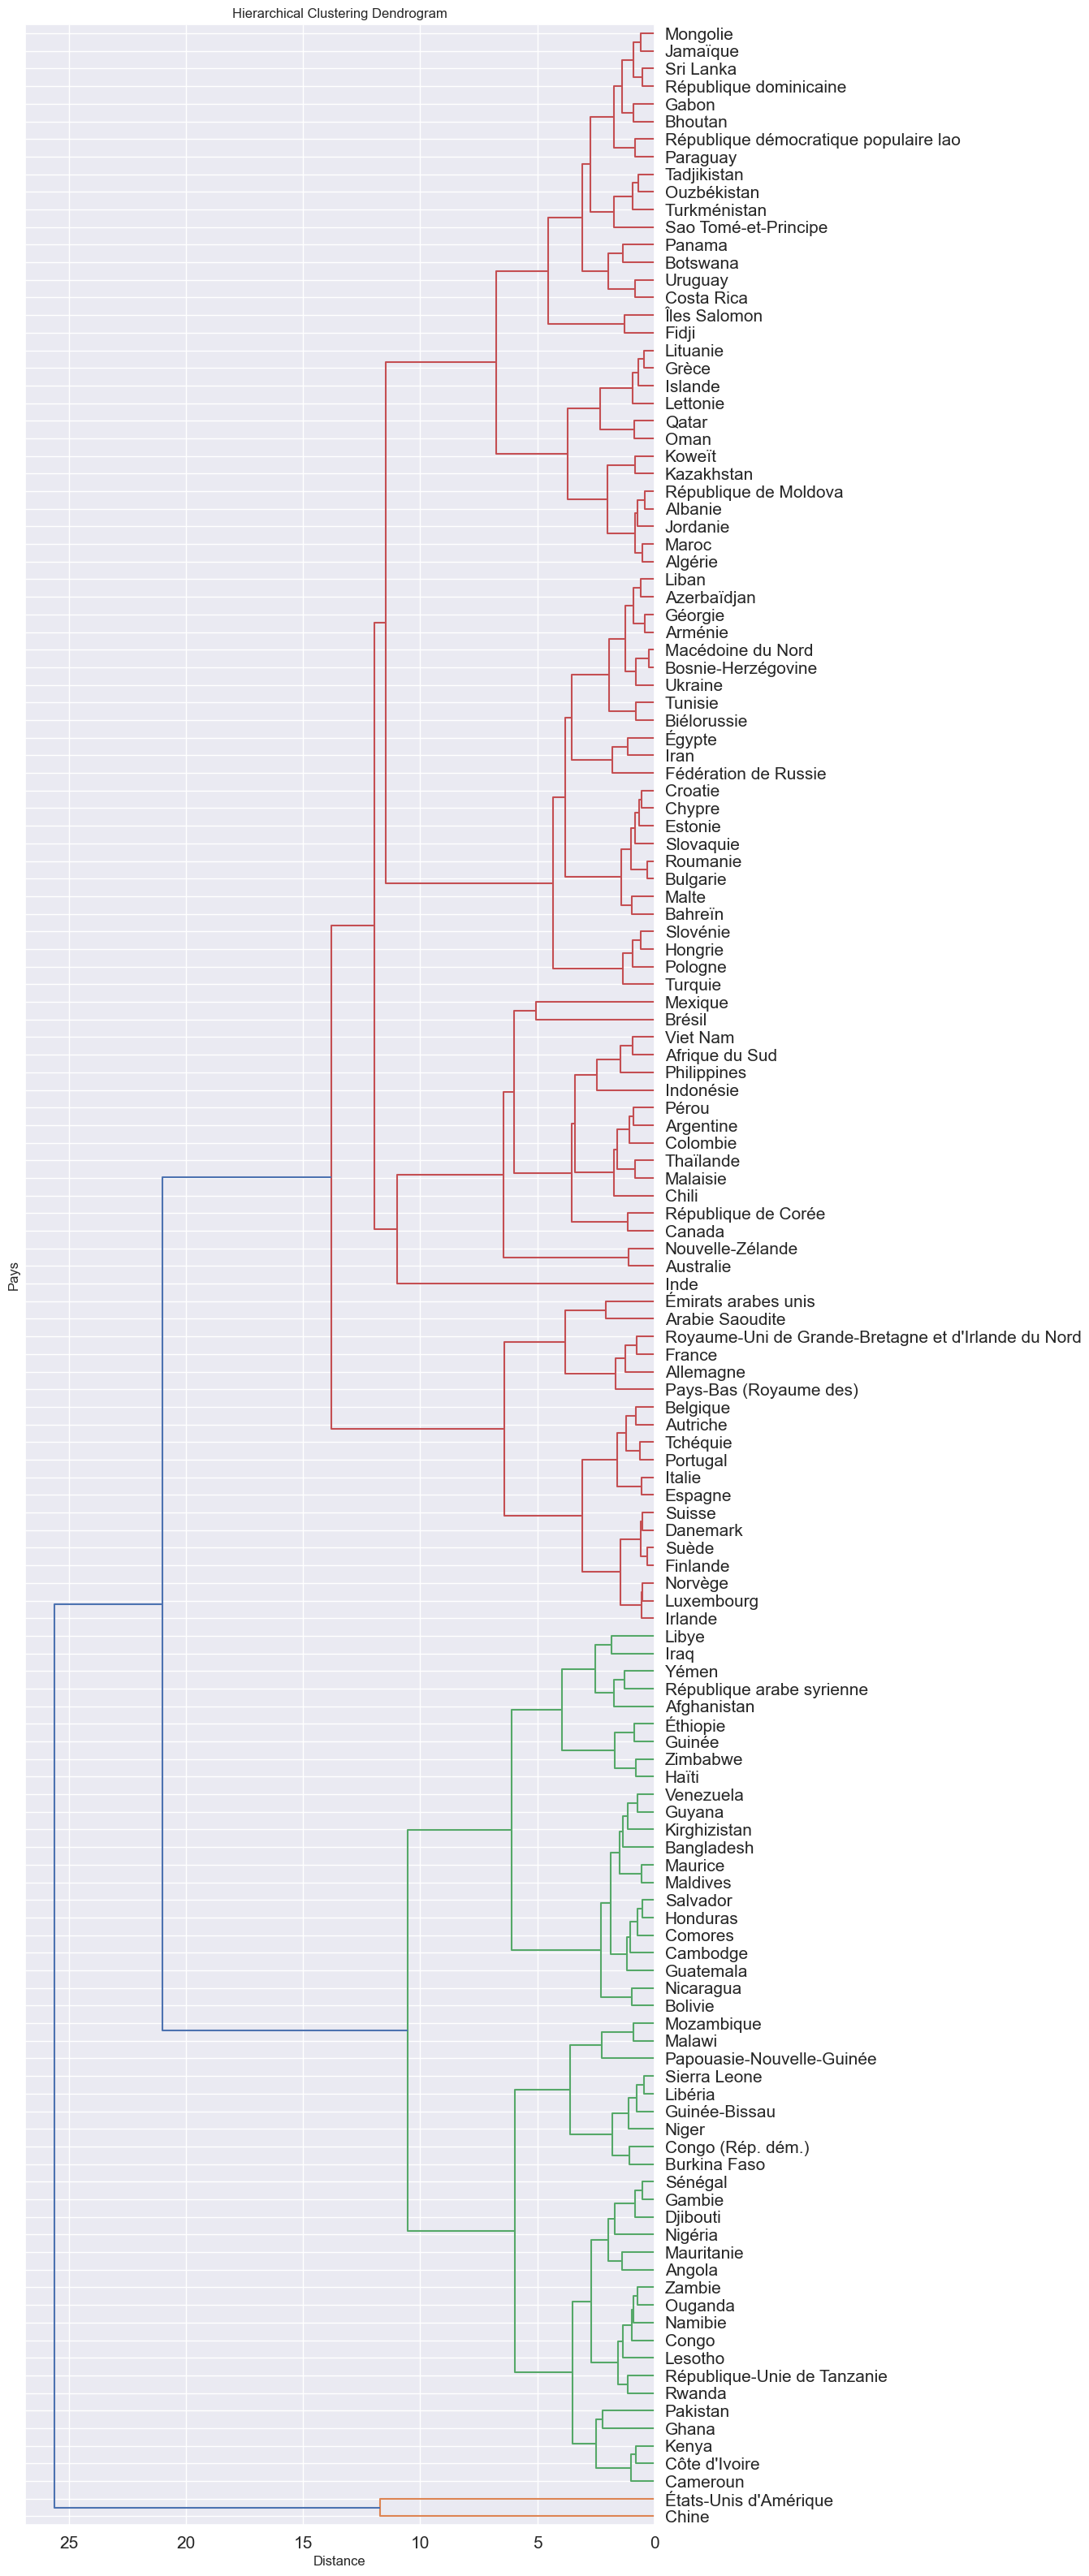

In [271]:
fig, ax = plt.subplots(1, 1, figsize=(10,40))

_ = dendrogram(Z, ax=ax, labels=names, orientation = "left")

plt.title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Distance")
ax.set_ylabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=15)
ax.tick_params(axis='y', which='major', labelsize=15)

In [272]:
k=6

In [273]:
clusters = fcluster(Z, k, criterion='maxclust')
clusters

array([3, 5, 6, 6, 4, 3, 4, 5, 6, 5, 4, 6, 6, 3, 4, 6, 6, 3, 6, 6, 5, 6,
       3, 3, 3, 5, 5, 1, 6, 5, 3, 3, 3, 6, 6, 3, 4, 3, 4, 6, 6, 4, 4, 6,
       6, 3, 3, 6, 3, 3, 3, 3, 6, 3, 3, 6, 5, 5, 6, 3, 4, 6, 4, 6, 6, 6,
       3, 3, 6, 3, 6, 6, 3, 3, 6, 4, 6, 5, 3, 3, 6, 6, 3, 3, 5, 6, 3, 3,
       3, 3, 3, 4, 5, 6, 3, 6, 3, 6, 3, 6, 4, 5, 6, 4, 5, 6, 6, 4, 3, 3,
       5, 6, 6, 6, 3, 3, 6, 3, 6, 6, 6, 4, 4, 3, 6, 4, 5, 6, 6, 6, 6, 6,
       3, 5, 3, 3, 3, 6, 4, 2, 3, 6], dtype=int32)

In [274]:
themes = df.Continent.values
themes

array(['Asia', 'Africa', 'Europe', 'Africa', 'Europe', 'Africa', 'Asia',
       'South America', 'Asia', 'Oceania', 'Europe', 'Asia', 'Asia',
       'Asia', 'Europe', 'Asia', 'Europe', 'South America', 'Europe',
       'Africa', 'South America', 'Europe', 'Africa', 'Asia', 'Africa',
       'North America', 'South America', 'Asia', 'Asia', 'South America',
       'Africa', 'Africa', 'Africa', 'North America', 'Europe', 'Africa',
       'Europe', 'Africa', 'Europe', 'Europe', 'Oceania', 'Europe',
       'Europe', 'Europe', 'Africa', 'Africa', 'Africa', 'Europe',
       'North America', 'Africa', 'Africa', 'South America', 'Asia',
       'North America', 'North America', 'Europe', 'Asia', 'Asia', 'Asia',
       'Asia', 'Europe', 'Europe', 'Europe', 'North America', 'Asia',
       'Asia', 'Africa', 'Asia', 'Asia', 'Africa', 'Europe', 'Asia',
       'Africa', 'Africa', 'Europe', 'Europe', 'Europe', 'Asia', 'Africa',
       'Asia', 'Europe', 'Africa', 'Africa', 'Africa', 'North America',
   

In [275]:
crosstab = pd.crosstab(themes, clusters, dropna=False)
crosstab.rename_axis(columns="cluster", index="theme", inplace=True)
crosstab

cluster,1,2,3,4,5,6
theme,,,,,,
Africa,0,0,31,0,1,7
Asia,1,0,9,2,7,20
Europe,0,0,0,17,0,20
North America,0,1,5,0,2,4
Oceania,0,0,1,0,2,2
South America,0,0,3,0,5,2


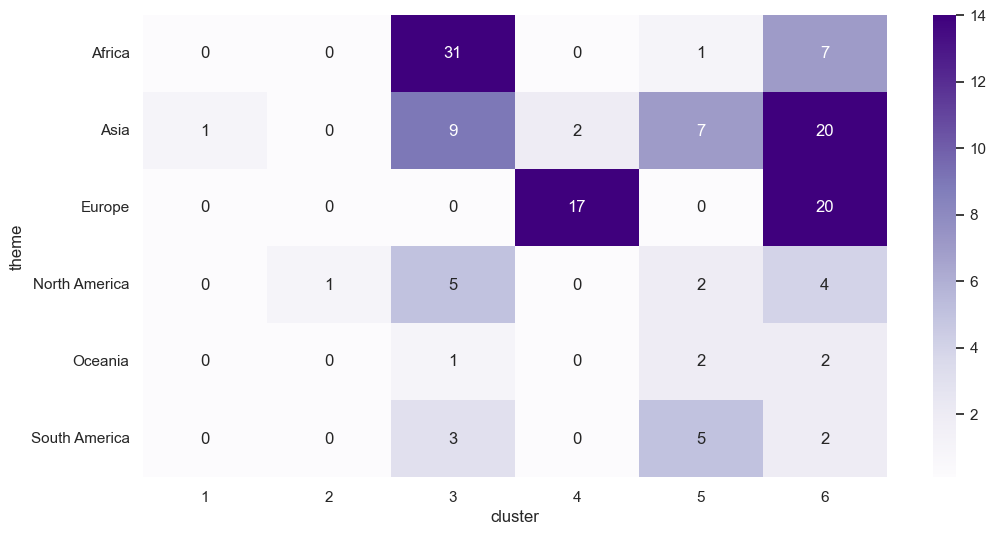

In [276]:
fig, ax = plt.subplots(1,1, figsize=(12,6))
ax = sns.heatmap(crosstab, vmin=0.1, vmax=14, annot=True, cmap="Purples")

In [277]:
df = pd.DataFrame({"name" : names, "theme" : themes, "cluster" : clusters})

In [278]:
df[df['cluster'] == 1]

,name,theme,cluster
27,Chine,Asia,1


In [279]:
df[df['cluster'] == 2]

,name,theme,cluster
139,États-Unis d'Amérique,North America,2


In [280]:
df[df['cluster'] == 3]

,name,theme,cluster
0,Afghanistan,Asia,3
5,Angola,Africa,3
13,Bangladesh,Asia,3
17,Bolivie,South America,3
22,Burkina Faso,Africa,3
23,Cambodge,Asia,3
24,Cameroun,Africa,3
30,Comores,Africa,3
31,Congo,Africa,3
32,Congo (Rép. dém.),Africa,3


In [281]:
df[df['cluster'] == 4]

,name,theme,cluster
4,Allemagne,Europe,4
6,Arabie Saoudite,Asia,4
10,Autriche,Europe,4
14,Belgique,Europe,4
36,Danemark,Europe,4
38,Espagne,Europe,4
41,Finlande,Europe,4
42,France,Europe,4
60,Irlande,Europe,4
62,Italie,Europe,4


In [282]:
df[df['cluster'] == 5]

,name,theme,cluster
1,Afrique du Sud,Africa,5
7,Argentine,South America,5
9,Australie,Oceania,5
20,Brésil,South America,5
25,Canada,North America,5
26,Chili,South America,5
29,Colombie,South America,5
56,Inde,Asia,5
57,Indonésie,Asia,5
77,Malaisie,Asia,5


In [283]:
df[df['cluster'] == 6]

,name,theme,cluster
2,Albanie,Europe,6
3,Algérie,Africa,6
8,Arménie,Asia,6
11,Azerbaïdjan,Asia,6
12,Bahreïn,Asia,6
15,Bhoutan,Asia,6
16,Biélorussie,Europe,6
18,Bosnie-Herzégovine,Europe,6
19,Botswana,Africa,6
21,Bulgarie,Europe,6


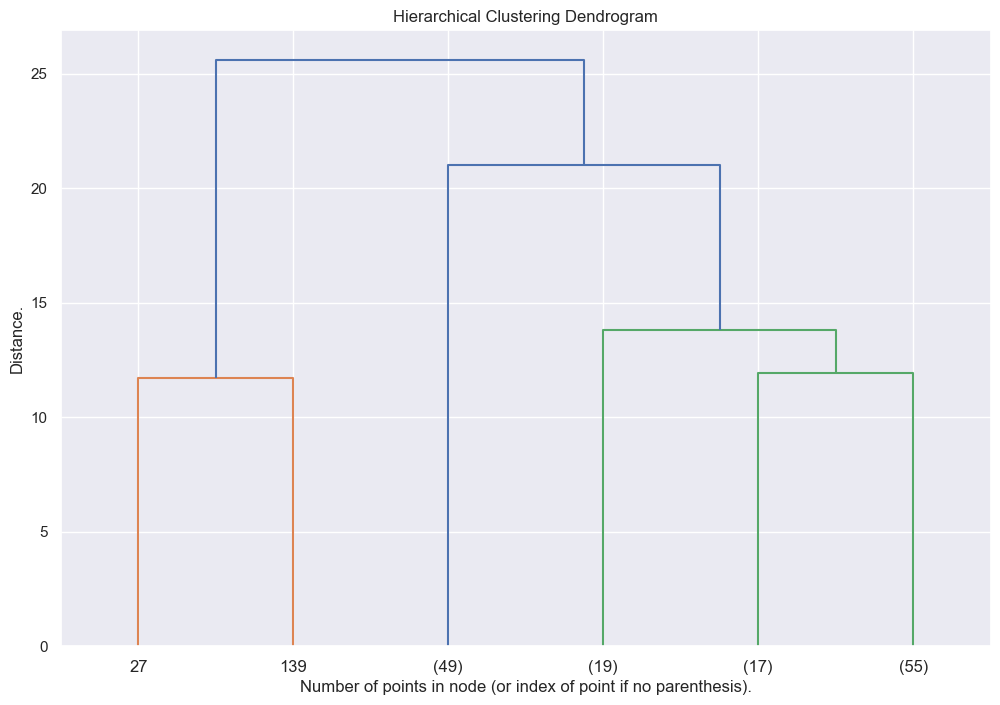

In [295]:
# les arguments p=6, truncate_mode="lastp" signifient que l'on ne va afficher que 10 clusters

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=6, truncate_mode="lastp", ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance.")
plt.show()

In [285]:
X = pd.DataFrame(X)
X.head()


,0,1,2,3,4,5,6,7,8
0,40000412.0,0.486,1.516092e+04,32613.38,1.463,97.7,1.95,60165.64,5590.3810
1,61502603.0,0.721,4.201178e+05,345579.16,0.319,89.3,3.38,2207246.75,9353.5520
2,2849635.0,0.794,1.793056e+04,21929.50,-0.630,100.0,2.66,35179.50,1603.5340
3,44761099.0,0.755,1.862317e+05,0.40,-0.857,99.8,2.45,271904.25,1340.3900
4,83697083.0,0.958,4.348297e+06,475448.52,-0.536,100.0,4.20,910325.80,439.8984


In [286]:
# On instancie notre Kmeans avec 3 clusters : 
kmeans = KMeans(n_clusters=3)

# On l'entraine : 
kmeans.fit(X)

# On peut stocker nos clusters dans une variable labels : 
labels = kmeans.labels_
labels


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 2, 0], dtype=int32)

In [287]:
# On peut stocker nos centroids dans une variable : 
centroids = kmeans.cluster_centers_
centroids


array([[2.08679701e+07, 7.42908397e-01, 2.89273571e+05, 7.44982091e+04,
        1.21770992e-01, 8.66267176e+01, 2.87804527e+00, 3.60592144e+05,
        5.39663092e+03],
       [1.43993155e+09, 7.20500000e-01, 1.06908940e+07, 1.12339353e+06,
        4.03500000e-01, 9.98000000e+01, 3.39500000e+00, 1.07508081e+07,
        7.40973100e+03],
       [2.05306516e+08, 6.90111111e-01, 3.44379574e+06, 1.48438679e+05,
        1.16955556e+00, 8.95888889e+01, 2.86075189e+00, 4.48831710e+06,
        6.96510767e+03]])

In [288]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [289]:
pca = PCA(n_components=3)
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [290]:
X_proj = pca.transform(X_scaled)
X_proj = pd.DataFrame(X_proj, columns = ["PC1", "PC2", "PC3"])
X_proj[:10]


,PC1,PC2,PC3
0,-1.396239,-1.351371,1.094503
1,0.944697,-0.381804,-0.496839
2,-0.301939,1.006960,0.072491
3,-0.377750,0.659551,0.018619
4,2.915306,1.803747,-0.452115
5,-1.255905,-1.648153,-1.021788
6,1.527908,0.667465,-1.096174
7,0.383407,-0.191154,0.890280
8,-0.371092,0.442258,1.353036
9,1.066578,0.808221,-1.705587


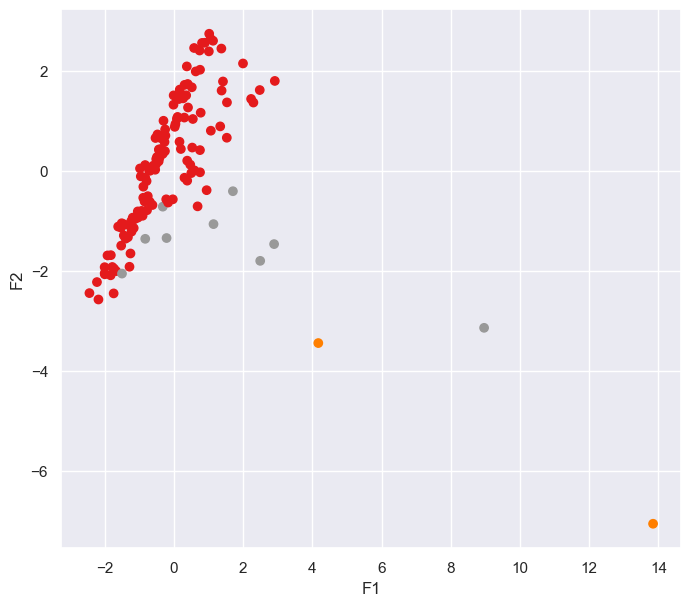

In [291]:
fig, ax = plt.subplots(1,1, figsize=(8,7))
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1")
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()


In [292]:
# On utilise bien le scaler déjà entrainé : 
centroids_scaled = scaler.fit_transform(centroids)

# et on utilise l'ACP déjà entrainée : 
centroids_proj = pca.transform(centroids_scaled)

# Création d'un dataframe pour plus de clarté:
centroids_proj = pd.DataFrame(centroids_proj, 
                              columns = ["F1", "F2", "F3"], 
                              index=["cluster_0", "cluster_1", "cluster_2"])

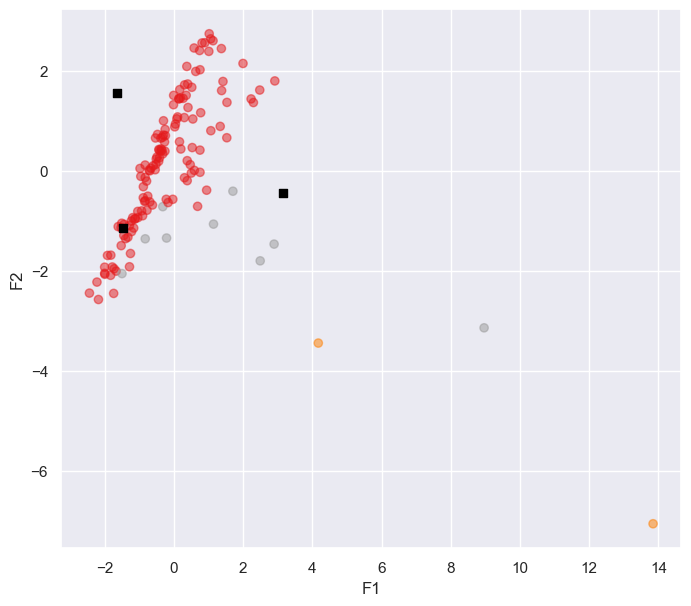

In [293]:
# On définit notre figure et son axe : 
fig, ax = plt.subplots(1,1, figsize=(8,7))

# On affiche nos individus, avec une transparence de 50% (alpha=0.5) : 
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1", alpha =0.5)

# On affiche nos centroides, avec une couleur noire (c="black") et une frome de carré (marker="c") : 
ax.scatter(centroids_proj.iloc[:, 0], centroids_proj.iloc[:, 1],  marker="s", c="black" )

# On spécifie les axes x et y :
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()


Text(0.5, 0, 'F3')

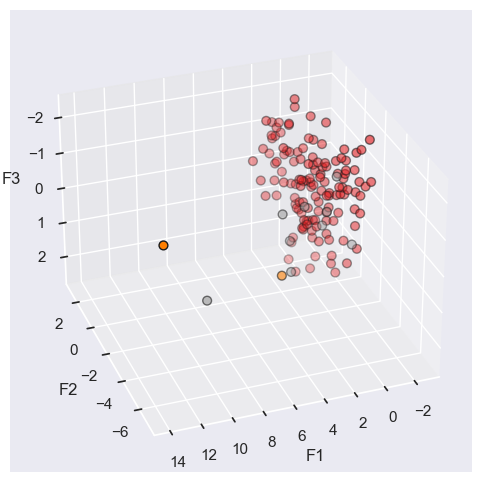

In [294]:
# On définit notre figure et notre axe différemment : 
fig= plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# On affiche nos points : 
ax.scatter(
    X_proj.iloc[:, 0],
    X_proj.iloc[:, 1],
    X_proj.iloc[:, 2],
    c=labels, cmap="Set1", edgecolor="k", s=40)

# On spécifie le nom des axes : 
ax.set_xlabel("F1")
ax.set_ylabel("F2")
ax.set_zlabel("F3")
